# Open-Meteo wind-cache viewer

Load the cached Open-Meteo profiles used by `montecarlorunner.py` and inspect how wind speed and meteorological direction vary with altitude. Relative-frequency heatmaps are normalized independently at every altitude, so each horizontal row represents the distribution across all cached weather calls.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Locate the configured cache

The notebook reads `environment.wind_sampling.cache_file` from the Monte Carlo configuration. Set `ALTITUDE_STEP_M` to control vertical resolution. By default, plots stop at the highest native Open-Meteo model top because winds above it are constant extensions rather than additional forecast data.

In [2]:
working_directory = Path.cwd().resolve()
project_candidates = [working_directory, working_directory / "sims" / "rocketpy", working_directory / "rocketpy"]
PROJECT_DIR = next((path for path in project_candidates if (path / "montecarlo_config.json").is_file()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError("Could not locate sims/rocketpy/montecarlo_config.json")

CONFIG_PATH = PROJECT_DIR / "montecarlo_config.json"
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
cache_setting = config.get("environment", {}).get("wind_sampling", {}).get("cache_file")
if not cache_setting:
    raise ValueError("environment.wind_sampling.cache_file is not configured")
CACHE_PATH = Path(cache_setting).expanduser()
if not CACHE_PATH.is_absolute():
    CACHE_PATH = (CONFIG_PATH.parent / CACHE_PATH).resolve()

ALTITUDE_STEP_M = 250.0
MAX_ALTITUDE_M = None
SPEED_BIN_COUNT = 30
DIRECTION_BIN_WIDTH_DEG = 15.0
print(f"Configuration: {CONFIG_PATH}")
print(f"Wind cache: {CACHE_PATH}")

Configuration: C:\Users\E\Documents\GitHub\farfromheaven\sims\rocketpy\montecarlo_config.json
Wind cache: C:\Users\E\Documents\GitHub\farfromheaven\sims\rocketpy\openmeteo_wind_cache.json


## Load and validate profiles

In [3]:
cache = json.loads(CACHE_PATH.read_text(encoding="utf-8"))
if cache.get("format") != "projectblaze.openmeteo.wind_profiles":
    raise ValueError(f"Unsupported cache format: {cache.get('format')!r}")
if cache.get("format_version") != 1:
    raise ValueError(f"Unsupported cache version: {cache.get('format_version')!r}")
profiles = cache.get("profiles", [])
if not profiles:
    raise ValueError("The weather cache contains no profiles")

profile_rows = []
for index, profile in enumerate(profiles):
    wind_u = np.asarray(profile.get("wind_u", ()), dtype=float)
    wind_v = np.asarray(profile.get("wind_v", ()), dtype=float)
    if wind_u.ndim != 2 or wind_v.ndim != 2 or wind_u.shape[1] != 2 or wind_v.shape[1] != 2:
        raise ValueError(f"Profile {index} has invalid wind arrays")
    profile_rows.append({
        "profile_index": index,
        "date": profile.get("date"),
        "time": profile.get("time"),
        "model_top_height_m": float(profile.get("model_top_height_m", np.nan)),
        "minimum_height_m": max(float(wind_u[0, 0]), float(wind_v[0, 0])),
        "maximum_height_m": min(float(wind_u[-1, 0]), float(wind_v[-1, 0])),
    })

profile_summary = pd.DataFrame.from_records(profile_rows)
print(f"Loaded {len(profiles):,} cached profiles")
print(f"Cache created: {cache.get('created_at_utc', 'unknown')}")
profile_summary.head()

Loaded 40 cached profiles
Cache created: 2026-08-25T07:16:29.765701Z


,profile_index,date,time,model_top_height_m,minimum_height_m,maximum_height_m
0,0,2026-08-28,00:00,31536.23,117.0,180000.0
1,1,2026-08-28,03:00,31507.25,110.0,180000.0
2,2,2026-08-28,06:00,31521.74,111.0,180000.0
3,3,2026-08-28,09:00,31507.25,137.0,180000.0
4,4,2026-08-28,12:00,31521.74,157.0,180000.0


## Interpolate onto a common altitude grid

Wind direction uses the meteorological convention: the direction the wind comes from, clockwise from north.

In [4]:
launch_elevation_m = float(cache.get("settings", {}).get("elevation_m", 0.0))
minimum_height_m = max(launch_elevation_m, float(profile_summary["minimum_height_m"].max()))
native_model_top_m = float(profile_summary["model_top_height_m"].min())
available_maximum_m = float(profile_summary["maximum_height_m"].min())
maximum_height_m = min(available_maximum_m, native_model_top_m if MAX_ALTITUDE_M is None else float(MAX_ALTITUDE_M))
if maximum_height_m <= minimum_height_m:
    raise ValueError("Cached profiles do not share a usable altitude interval")
altitude_m = np.arange(minimum_height_m, maximum_height_m + ALTITUDE_STEP_M, ALTITUDE_STEP_M)
altitude_m = altitude_m[altitude_m <= maximum_height_m]

wind_u_by_profile = []
wind_v_by_profile = []
for profile in profiles:
    wind_u = np.asarray(profile["wind_u"], dtype=float)
    wind_v = np.asarray(profile["wind_v"], dtype=float)
    wind_u_by_profile.append(np.interp(altitude_m, wind_u[:, 0], wind_u[:, 1]))
    wind_v_by_profile.append(np.interp(altitude_m, wind_v[:, 0], wind_v[:, 1]))

wind_u_by_profile = np.asarray(wind_u_by_profile)
wind_v_by_profile = np.asarray(wind_v_by_profile)
wind_speed_m_s = np.hypot(wind_u_by_profile, wind_v_by_profile)
wind_direction_deg = np.degrees(np.arctan2(-wind_u_by_profile, -wind_v_by_profile)) % 360.0
print(f"Common grid: {len(altitude_m):,} levels from {altitude_m[0]:,.0f} to {altitude_m[-1]:,.0f} m ASL")

Common grid: 122 levels from 1,191 to 31,441 m ASL


## Cached wind profiles

These overlays show every cached weather call before aggregation into relative frequencies.

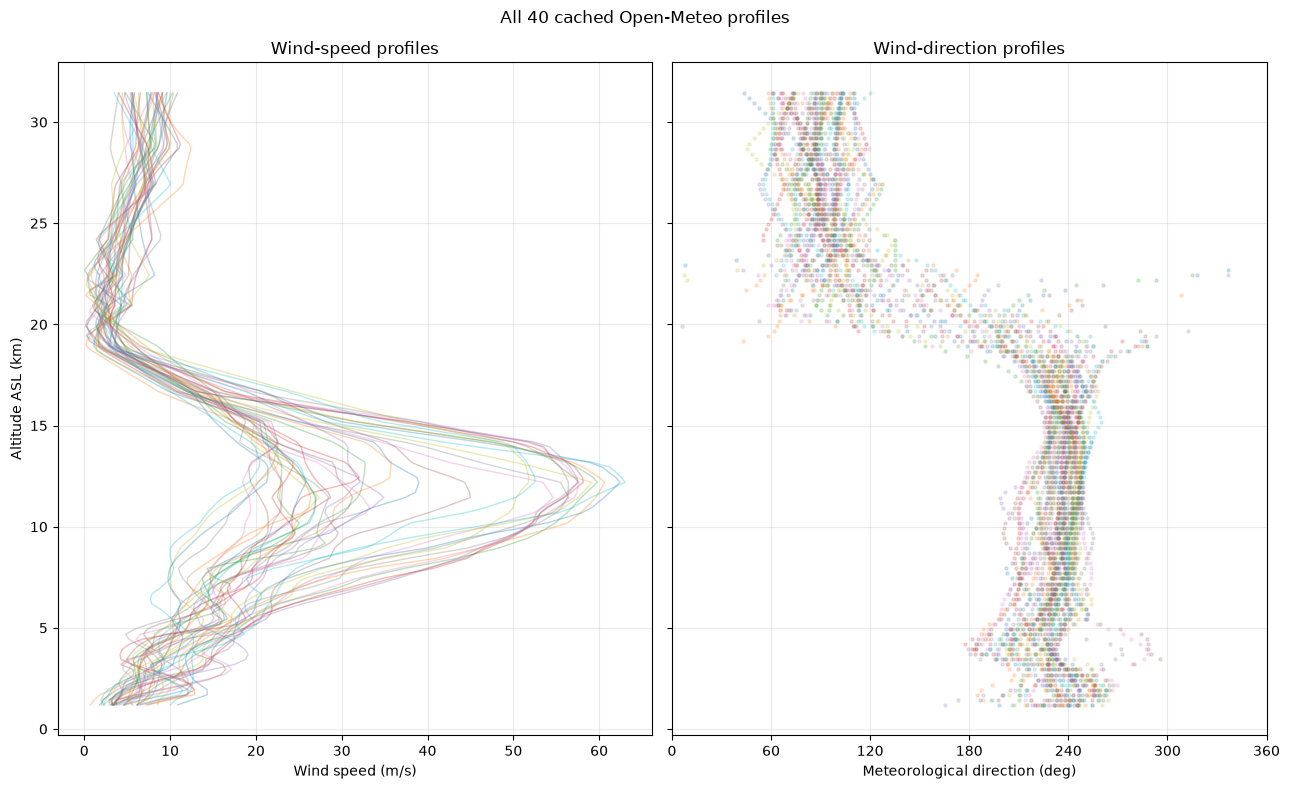

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=True)
altitude_km = altitude_m / 1000.0
for profile_index in range(len(profiles)):
    axes[0].plot(wind_speed_m_s[profile_index], altitude_km, alpha=0.32, linewidth=1)
    axes[1].scatter(wind_direction_deg[profile_index], altitude_km, alpha=0.18, s=5)
axes[0].set_title("Wind-speed profiles")
axes[0].set_xlabel("Wind speed (m/s)")
axes[0].set_ylabel("Altitude ASL (km)")
axes[1].set_title("Wind-direction profiles")
axes[1].set_xlabel("Meteorological direction (deg)")
axes[1].set_xlim(0, 360)
axes[1].set_xticks(np.arange(0, 361, 60))
for axis in axes:
    axis.grid(alpha=0.25)
fig.suptitle(f"All {len(profiles):,} cached Open-Meteo profiles")
fig.tight_layout()
plt.show()

## Relative frequency versus altitude

Each altitude row is normalized separately. A value of 25% means one quarter of cached profiles fall in that speed or direction bin at that altitude.

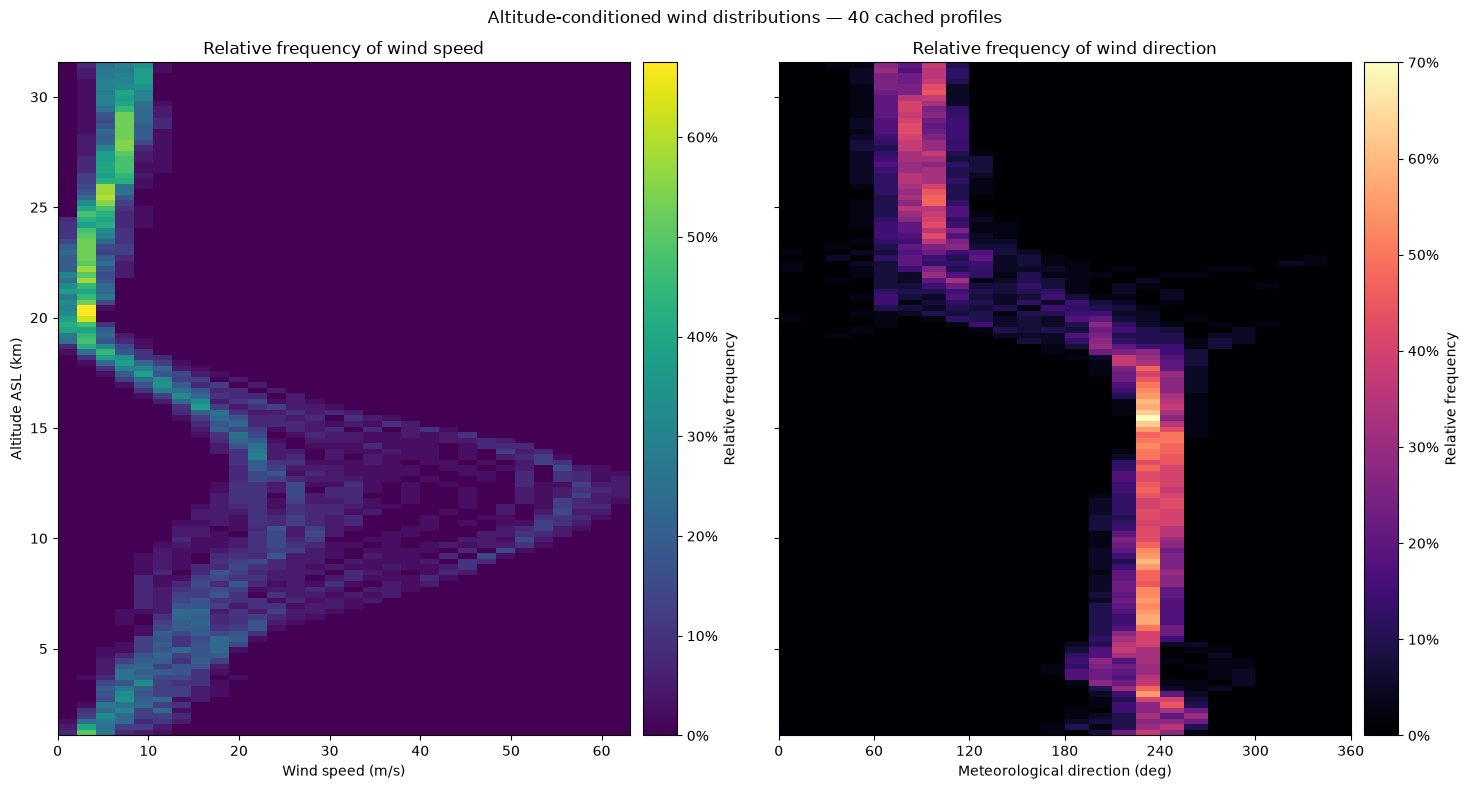

In [6]:
maximum_speed = float(np.nanmax(wind_speed_m_s))
speed_edges = np.linspace(0.0, maximum_speed * 1.001, SPEED_BIN_COUNT + 1)
direction_edges = np.arange(0.0, 360.0 + DIRECTION_BIN_WIDTH_DEG, DIRECTION_BIN_WIDTH_DEG)

def relative_frequency_by_altitude(values_by_profile, bin_edges):
    frequencies = np.empty((len(altitude_m), len(bin_edges) - 1), dtype=float)
    for altitude_index in range(len(altitude_m)):
        values = values_by_profile[:, altitude_index]
        values = values[np.isfinite(values)]
        counts, _ = np.histogram(values, bins=bin_edges)
        frequencies[altitude_index] = counts / counts.sum() if counts.sum() else 0.0
    return frequencies

speed_frequency = relative_frequency_by_altitude(wind_speed_m_s, speed_edges)
direction_frequency = relative_frequency_by_altitude(wind_direction_deg, direction_edges)
altitude_edges_m = np.concatenate(([altitude_m[0] - ALTITUDE_STEP_M / 2], altitude_m + ALTITUDE_STEP_M / 2))

fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
speed_mesh = axes[0].pcolormesh(speed_edges, altitude_edges_m / 1000.0, speed_frequency, shading="auto", cmap="viridis", vmin=0)
direction_mesh = axes[1].pcolormesh(direction_edges, altitude_edges_m / 1000.0, direction_frequency, shading="auto", cmap="magma", vmin=0)
axes[0].set_title("Relative frequency of wind speed")
axes[0].set_xlabel("Wind speed (m/s)")
axes[0].set_ylabel("Altitude ASL (km)")
axes[1].set_title("Relative frequency of wind direction")
axes[1].set_xlabel("Meteorological direction (deg)")
axes[1].set_xlim(0, 360)
axes[1].set_xticks(np.arange(0, 361, 60))
speed_colorbar = fig.colorbar(speed_mesh, ax=axes[0], pad=0.02)
direction_colorbar = fig.colorbar(direction_mesh, ax=axes[1], pad=0.02)
speed_colorbar.set_label("Relative frequency")
direction_colorbar.set_label("Relative frequency")
for colorbar in (speed_colorbar, direction_colorbar):
    colorbar.ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))
fig.suptitle(f"Altitude-conditioned wind distributions — {len(profiles):,} cached profiles")
fig.tight_layout()
plt.show()

## Distribution summary

In [7]:
summary = pd.DataFrame({
    "altitude_m_asl": altitude_m,
    "speed_mean_m_s": np.mean(wind_speed_m_s, axis=0),
    "speed_std_m_s": np.std(wind_speed_m_s, axis=0, ddof=1) if len(profiles) > 1 else 0.0,
    "speed_min_m_s": np.min(wind_speed_m_s, axis=0),
    "speed_max_m_s": np.max(wind_speed_m_s, axis=0),
})
summary.iloc[::max(1, len(summary) // 20)].round(2)

,altitude_m_asl,speed_mean_m_s,speed_std_m_s,speed_min_m_s,speed_max_m_s
0,1191.0,4.48,2.18,0.72,10.88
6,2691.0,8.91,2.83,4.68,16.29
12,4191.0,11.41,3.42,5.25,17.97
18,5691.0,15.99,3.69,9.58,21.73
24,7191.0,19.52,6.79,9.44,34.46
30,8691.0,26.48,10.85,10.01,45.85
36,10191.0,33.48,13.80,13.52,56.34
42,11691.0,37.19,15.51,17.11,61.20
48,13191.0,35.53,14.33,19.48,59.07
54,14691.0,27.91,9.65,16.45,45.37
